Sedang memuat model Amazon Chronos...
Melakukan prediksi untuk 12 bulan ke depan berdasarkan Inflasi_MoM...


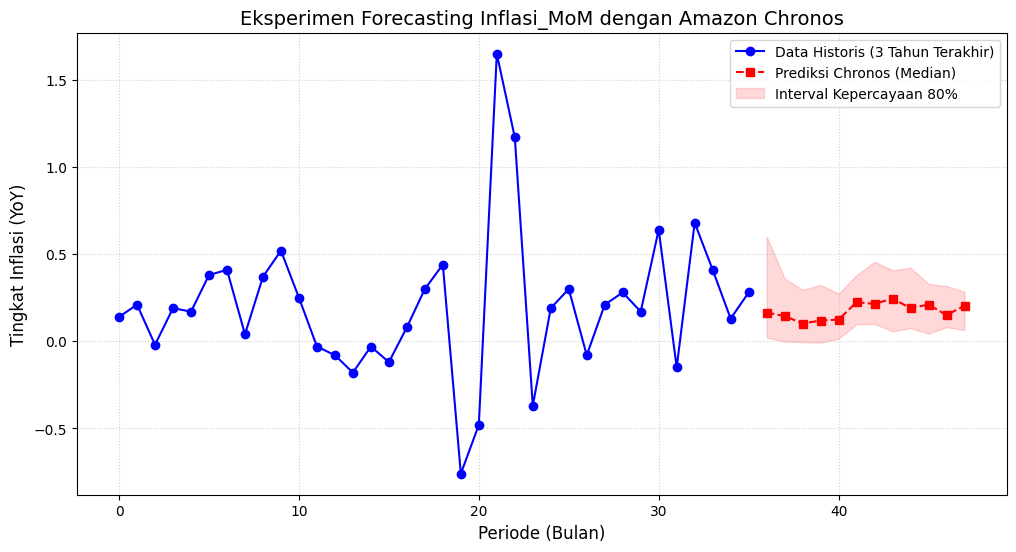

In [12]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

# 1. Load Model Amazon Chronos
print("Sedang memuat model Amazon Chronos...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-mini",
    device_map="cpu",
    torch_dtype=torch.float32,
)

# 2. Baca Data dengan Deteksi Pemisah Otomatis & Bersihkan Nama Kolom 🎯
path_file = '/Users/adrinafirda/ml/Project-Machine-Learning/datasets/processed/clean_inflasi_ts.csv'

# Menggunakan sep=None dan engine='python' agar Pandas otomatis menebak pemisahnya (apakah koma, titik koma, atau Tab)
df = pd.read_csv(path_file, sep=None, engine='python')

# [KUNCI SUKSES] Hilangkan semua spasi tak terlihat di awal/akhir nama kolom
df.columns = df.columns.str.strip()

# Set target kolom sesuai keyakinanmu
nama_kolom = 'Inflasi_MoM'

# Validasi darurat: kalau ternyata namanya mirip tapi beda huruf besar/kecil
if nama_kolom not in df.columns:
    # Cari nama kolom yang mengandung kata 'YoY' secara fleksibel
    kolom_mirip = [c for c in df.columns if 'YoY' in c]
    if kolom_mirip:
        nama_kolom = kolom_mirip[0]
        print(f"Menyesuaikan nama kolom menjadi: '{nama_kolom}'")
    else:
        raise KeyError(f"Kolom 'Inflasi_MoM' beneran gak ketemu. Kolom yang ada: {df.columns.tolist()}")

# Ambil datanya, bersihkan dari nilai kosong (NaN) jika ada
nilai_inflasi = df[nama_kolom].dropna().values
context = torch.tensor(nilai_inflasi, dtype=torch.float32)

# 3. Lakukan Forecasting (Prediksi 12 bulan ke depan)
jumlah_prediksi = 12
print(f"Melakukan prediksi untuk {jumlah_prediksi} bulan ke depan berdasarkan {nama_kolom}...")
forecast = pipeline.predict(context, prediction_length=jumlah_prediksi)

# 4. Ambil Nilai Tengah (Median) dan Interval Kepercayaan
low, median, high = np.percentile(forecast[0].numpy(), [10, 50, 90], axis=0)

# 5. Visualisasikan Hasilnya! 📊
plt.figure(figsize=(12, 6))

# Plot data historis asli (3 tahun terakhir)
tampilkan_bulan_terakhir = 36
historis_plot = nilai_inflasi[-tampilkan_bulan_terakhir:]
x_historis = range(len(historis_plot))

plt.plot(x_historis, historis_plot, label="Data Historis (3 Tahun Terakhir)", color="blue", marker='o')

# Plot hasil ramalan Chronos ke depan
x_prediksi = range(len(historis_plot), len(historis_plot) + jumlah_prediksi)
plt.plot(x_prediksi, median, label="Prediksi Chronos (Median)", color='red', linestyle='--', marker='s')
plt.fill_between(x_prediksi, low, high, color='red', alpha=0.15, label="Interval Kepercayaan 80%")

plt.title(f"Eksperimen Forecasting {nama_kolom} dengan Amazon Chronos", fontsize=14)
plt.xlabel("Periode (Bulan)", fontsize=12)
plt.ylabel("Tingkat Inflasi (YoY)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [13]:
import pandas as pd
import numpy as np
import torch
from chronos import ChronosPipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load Model Amazon Chronos
print("Sedang memuat model Amazon Chronos...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-mini",
    device_map="cpu",
    torch_dtype=torch.float32,
)

# 2. Baca Data
path_file = '/Users/adrinafirda/ml/Project-Machine-Learning/Project-Machine-Learning/datasets/processed/clean_inflasi_ts.csv'
df = pd.read_csv(path_file)
nama_kolom = 'Inflasi_MoM'
nilai_inflasi = df[nama_kolom].dropna().values

# 3. BACKTESTING: Potong data untuk Simulasi Evaluasi 🎯
jumlah_evaluasi = 12  # Kita uji untuk 12 bulan terakhir yang sudah ada nilainya

# Context adalah data masa lalu SEBELUM 12 bulan terakhir
context_eval = nilai_inflasi[:-jumlah_evaluasi]
# Aktual adalah nilai asli 12 bulan terakhir untuk dicocokkan
aktual = nilai_inflasi[-jumlah_evaluasi:]

# 4. Lakukan Prediksi untuk Masa Lalu Tersebut
context_tensor = torch.tensor(context_eval, dtype=torch.float32)
forecast = pipeline.predict(context_tensor, prediction_length=jumlah_evaluasi)

# Ambil nilai median hasil tebakan Chronos
prediksi_chronos = np.percentile(forecast[0].numpy(), 50, axis=0)

# 5. Hitung Metrik Evaluasi Error 📊
mae = mean_absolute_error(aktual, prediksi_chronos)
rmse = np.sqrt(mean_squared_error(aktual, prediksi_chronos))
me = np.mean(prediksi_chronos - aktual)  # Mean Error (buat melihat bias)

# Tambahan MAPE (Mean Absolute Percentage Error) dengan pengaman jika ada nilai aktual = 0
with np.errstate(divide='ignore', invalid='ignore'):
    mape = np.mean(np.abs((aktual - prediksi_chronos) / aktual)) * 100

# 6. Print Hasilnya dengan Rapi ✨
print("\n" + "="*40)
print(f" METRIK EVALUASI ERROR AMAZON CHRONOS ({nama_kolom})")
print("="*40)
print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"Mean Error (ME)                : {me:.4f}")
if not np.isinf(mape) and not np.isnan(mape):
    print(f"Mean Absolute Pct Error (MAPE) : {mape:.2f}%")
else:
    print("Mean Absolute Pct Error (MAPE) : Tidak dapat dihitung (ada nilai aktual 0%)")
print("="*40)

Sedang memuat model Amazon Chronos...

 METRIK EVALUASI ERROR AMAZON CHRONOS (Inflasi_MoM)
Mean Absolute Error (MAE)      : 0.4229
Root Mean Squared Error (RMSE) : 0.6065
Mean Error (ME)                : -0.2358
Mean Absolute Pct Error (MAPE) : 94.42%
